In [1]:
import pandas as pd
import numpy as np

In [2]:
df = pd.read_csv("/content/Iris.csv")

In [3]:
df.head()

,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1,3.5,1.4,0.2,Iris-setosa
1,2,4.9,3.0,1.4,0.2,Iris-setosa
2,3,4.7,3.2,1.3,0.2,Iris-setosa
3,4,4.6,3.1,1.5,0.2,Iris-setosa
4,5,5.0,3.6,1.4,0.2,Iris-setosa


In [5]:
df = df.iloc[:,1:]
df.head()

,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,3.5,1.4,0.2,Iris-setosa
1,3.0,1.4,0.2,Iris-setosa
2,3.2,1.3,0.2,Iris-setosa
3,3.1,1.5,0.2,Iris-setosa
4,3.6,1.4,0.2,Iris-setosa


In [6]:
from sklearn.preprocessing import LabelEncoder

In [7]:
le = LabelEncoder()

In [9]:
df['Species']=le.fit_transform(df['Species'])

In [11]:
df = df[df['Species'] !=-0][['SepalWidthCm','PetalLengthCm','Species']]

In [12]:
df.head()

,SepalWidthCm,PetalLengthCm,Species
50,3.2,4.7,1
51,3.2,4.5,1
52,3.1,4.9,1
53,2.3,4.0,1
54,2.8,4.6,1


In [14]:
import seaborn as sns
import matplotlib.pyplot as plt

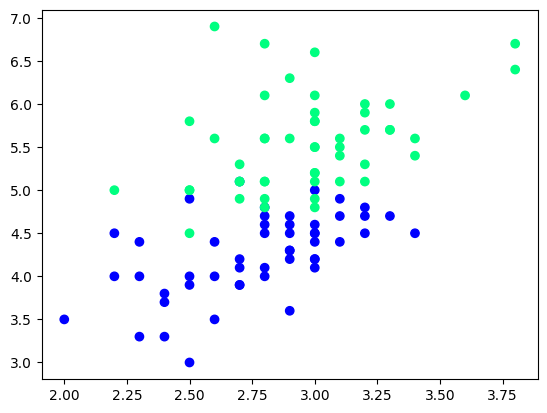

In [16]:
plt.scatter(x=df['SepalWidthCm'],y=df['PetalLengthCm'],c=df['Species'],cmap='winter')

In [18]:
## taking only 10 rows for the trainig
df = df.sample(100)
df_train = df.iloc[:60,:].sample(10)
df_val = df.iloc[60:80,:].sample(5)
df_test = df.iloc[80:,:].sample(5)

In [22]:
df_test

,SepalWidthCm,PetalLengthCm,Species
59,2.7,3.9,1
87,2.3,4.4,1
148,3.4,5.4,2
65,3.1,4.4,1
120,3.2,5.7,2


In [23]:
X_test = df_val.iloc[:,0:2].values
y_test = df_val.iloc[:,-1].values

In [24]:
X_test

array([[2.3, 3.3],
       [3.4, 5.6],
       [3.8, 6.4],
       [3.2, 5.1],
       [3. , 5.2]])

In [25]:
y_test

array([1, 2, 2, 2, 2])

## Type 1: Bagging (Row Sampling with replacement)

## Bootstrapping

In [28]:
## we will train 3 baseline models
df_bag = df_train.sample(8,replace=True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

In [34]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.tree import plot_tree
from mlxtend.plotting import plot_decision_regions
from sklearn.metrics import accuracy_score

In [35]:
dt1 = DecisionTreeClassifier()

In [38]:
def evaluate(model,X,y):
  model.fit(X,y)
  plot_tree(model)
  plt.show()
  plot_decision_regions(X.values,y.values,clf=model,legend=2)
  y_pred = model.predict(X_test)
  print(accuracy_score(y_test,y_pred))

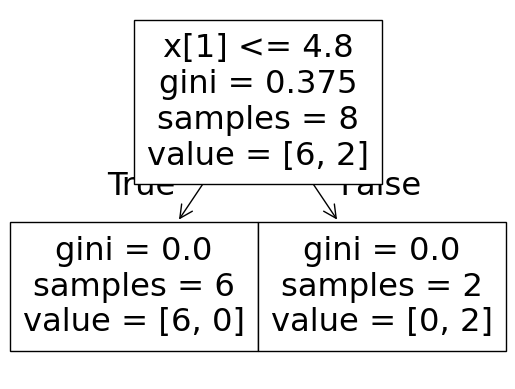

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


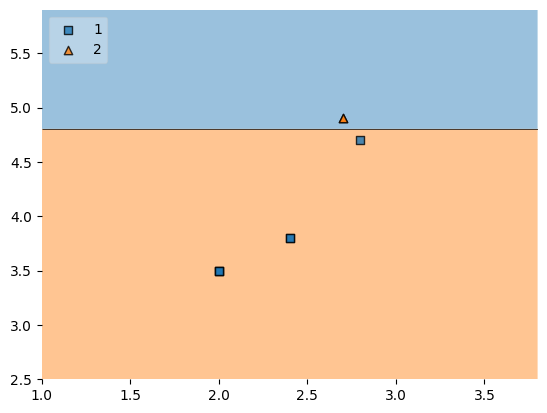

In [39]:
evaluate(dt1,X,y)

In [41]:
y

,Species
123,2
60,1
73,1
80,1
60,1
123,2
60,1
80,1


In [42]:
## training 2nd Baseline model
df_bag = df_train.sample(8,replace=True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

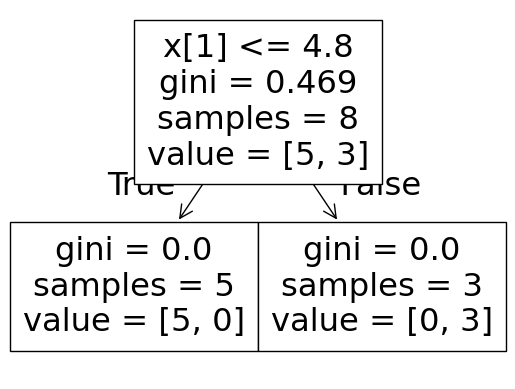

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


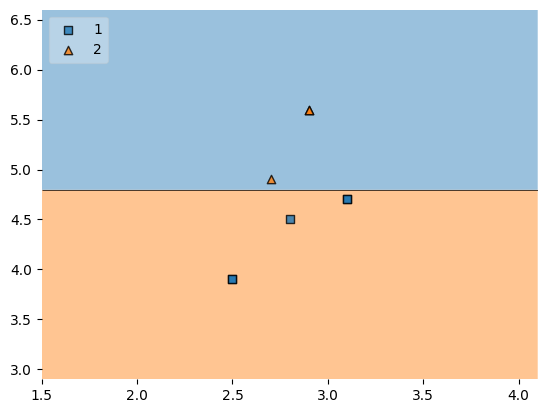

In [44]:
dt2 = DecisionTreeClassifier()
evaluate(dt2,X,y)

In [45]:
## training 3rd Baseline model
df_bag = df_train.sample(8,replace=True)
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

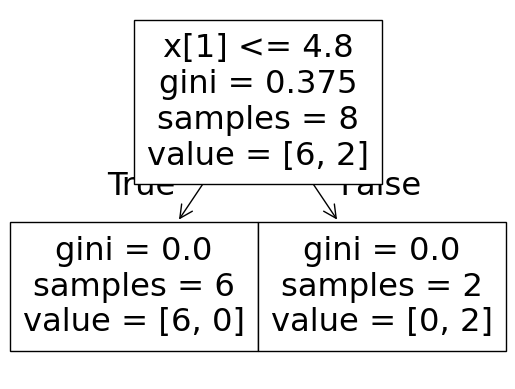

/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


1.0


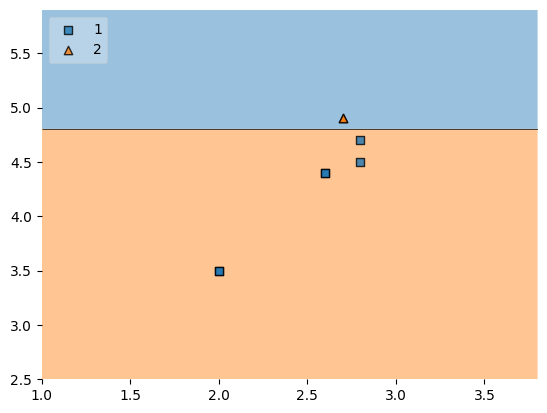

In [46]:
dt3 = DecisionTreeClassifier()
evaluate(dt3,X,y)

## Prediction ---(Aggregation)

In [47]:
df_test

,SepalWidthCm,PetalLengthCm,Species
59,2.7,3.9,1
87,2.3,4.4,1
148,3.4,5.4,2
65,3.1,4.4,1
120,3.2,5.7,2


In [49]:
print("Predictor 1:",dt1.predict(np.array([2.7,3.9]).reshape(1,2)))
print("Predictor 2:",dt2.predict(np.array([2.7,3.9]).reshape(1,2)))
print("Predictor 3:",dt3.predict(np.array([2.7,3.9]).reshape(1,2)))

Predictor 1: [1]
Predictor 2: [1]
Predictor 3: [1]


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(


## Type 2: Pasting (Row Sampling but w/o replacement)

In [50]:
## we will train 3 baseline models
df_bag = df_train.sample(8)  #replace is false here
X = df_bag.iloc[:,0:2]
y = df_bag.iloc[:,-1]

## Type 3: Random Subspaces (Col Sampling w or w/o replacement)

In [54]:
df_train.sample(2,axis=1)  ##column sampling w/o replacement
df_train.sample(2,axis=1,replace=True)  ##column sampling w replacement

,Species,PetalLengthCm
73,1,4.7
60,1,3.5
90,1,4.4
55,1,4.5
69,1,3.9
86,1,4.7
80,1,3.8
103,2,5.6
123,2,4.9
63,1,4.7


## Type 4: Random Patches (Combination of row and column sampling)

In [55]:
df.sample(8,replace=True).sample(2,replace=True,axis=1)

,Species,PetalLengthCm
146,2,5.0
148,2,5.4
141,2,5.1
97,1,4.3
102,2,5.9
53,1,4.0
102,2,5.9
131,2,6.4
